# Data Observation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
REGIONS_NUMBER = 3108

TRAIN_DAYS_NUMBER = 5480
TEST_DAYS_NUMBER = 91

In [47]:
def file_csv_to_df(train):
    name = "train" if train else "test"
    df = pd.read_csv(f"data/{name}.csv")

    numeric_cols = [
        "tmp", "tmp_min", "tmp_max", "tmp_range",
        "wind", "wind_min", "wind_max", "wind_range",
        "surf_tmp", "surf_pre",
        "dp_tmp", "wb_tmp",
        "prec", "score"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Fill NaN scores with the last day's score in each 7-row week
    df["score"] = df.groupby(df.index // 7)["score"].transform(lambda s: s.bfill())

    return df

def region_df(df, region_id):
    assert 1 <= int(region_id[1:]) and int(region_id[1:]) <= REGIONS_NUMBER
    
    return df[df['region_id'] == region_id]

In [41]:
def data_frame_to_figures(df):
    df = df.sort_values("date").reset_index(drop=True)

    fig, axes = plt.subplots(6, 1, sharex=True, figsize=(15, 8))

    dates = df["date"].tolist()
    score = df["score"].fillna(0).astype(int).clip(0, 5)

    drought_colors = [
        "#fff7ec",  # 0
        "#fee8c8",  # 1
        "#fdd49e",  # 2
        "#fdbb84",  # 3
        "#fc8d59",  # 4
        "#b30000",  # 5
    ]

    def add_drought_background(ax):
        for i in range(len(dates) - 1):
            ax.axvspan(
                dates[i],
                dates[i + 1],
                color=drought_colors[score.iloc[i]],
                alpha=0.18,
                lw=0,
                zorder=0,
            )

    # Temperature
    ax = axes[0]
    add_drought_background(ax)
    ax.plot(dates, df["tmp"], color="red", label="mean", lw=0.5, zorder=1)
    ax.plot(dates, df["tmp_range"], color="orange", label="range", lw=0.5, zorder=1)
    ax.fill_between(dates, df["tmp_min"], df["tmp_max"], color="red", alpha=0.2, label="min/max", zorder=1)
    ax.set_title("Temperature")
    ax.legend()

    # Wind
    ax = axes[1]
    add_drought_background(ax)
    ax.plot(dates, df["wind"], color="blue", label="mean", lw=0.5, zorder=1)
    ax.plot(dates, df["wind_range"], color="green", label="range", lw=0.5, zorder=1)
    ax.fill_between(dates, df["wind_min"], df["wind_max"], color="blue", alpha=0.2, label="min/max", zorder=1)
    ax.set_title("Wind Speed")
    ax.legend()

    # Surface temperature
    ax = axes[2]
    add_drought_background(ax)
    ax.plot(dates, df["surf_tmp"], color="gold", lw=0.5, zorder=1)
    ax.set_title("Surface Temperature")

    # Surface pressure
    ax = axes[3]
    add_drought_background(ax)
    ax.plot(dates, df["surf_pre"], color="gold", lw=0.5, zorder=1)
    ax.set_title("Surface Pressure")

    # Dew point / wet bulb
    ax = axes[4]
    add_drought_background(ax)
    ax.plot(dates, df["dp_tmp"], color="darkblue", label="dp", lw=0.5, zorder=1)
    ax.plot(dates, df["wb_tmp"], color="gray", label="wb", lw=0.5, zorder=1)
    ax.set_title("Dew Point / Wet Bulb Temperature")
    ax.legend()

    # Precipitation
    ax = axes[5]
    add_drought_background(ax)
    ax.plot(dates, df["prec"], color="blue", lw=0.5, zorder=1)
    ax.set_title("Precipitation")

    plt.tight_layout()
    plt.show()

In [48]:
df = file_csv_to_df(True)
df.head()

,region_id,date,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,tmp_range,surf_tmp,wind,wind_max,wind_min,wind_range,score
0,R1,3004-12-31,0.00,101.27,3.76,5.89,-0.14,-0.11,14.87,-2.37,17.24,4.23,1.45,2.58,0.24,2.34,0.0
1,R1,3005-01-01,0.00,101.26,5.37,8.81,4.59,4.60,17.28,1.14,16.14,7.96,1.83,2.38,1.18,1.21,0.0
2,R1,3005-01-02,0.01,100.81,9.32,13.09,12.74,12.74,17.38,8.21,9.17,12.96,1.96,2.49,1.39,1.09,0.0
3,R1,3005-01-03,0.02,100.51,11.40,16.01,16.08,16.08,19.24,13.77,5.47,15.82,2.13,2.67,1.74,0.93,0.0
4,R1,3005-01-04,1.93,100.16,12.20,17.98,17.04,17.04,22.85,14.27,8.58,17.86,2.91,4.25,2.13,2.11,0.0


In [49]:
df_1 = region_df(df, 'R1')
df_1.head()

,region_id,date,prec,surf_pre,humidity,tmp,dp_tmp,wb_tmp,tmp_max,tmp_min,tmp_range,surf_tmp,wind,wind_max,wind_min,wind_range,score
0,R1,3004-12-31,0.00,101.27,3.76,5.89,-0.14,-0.11,14.87,-2.37,17.24,4.23,1.45,2.58,0.24,2.34,0.0
1,R1,3005-01-01,0.00,101.26,5.37,8.81,4.59,4.60,17.28,1.14,16.14,7.96,1.83,2.38,1.18,1.21,0.0
2,R1,3005-01-02,0.01,100.81,9.32,13.09,12.74,12.74,17.38,8.21,9.17,12.96,1.96,2.49,1.39,1.09,0.0
3,R1,3005-01-03,0.02,100.51,11.40,16.01,16.08,16.08,19.24,13.77,5.47,15.82,2.13,2.67,1.74,0.93,0.0
4,R1,3005-01-04,1.93,100.16,12.20,17.98,17.04,17.04,22.85,14.27,8.58,17.86,2.91,4.25,2.13,2.11,0.0


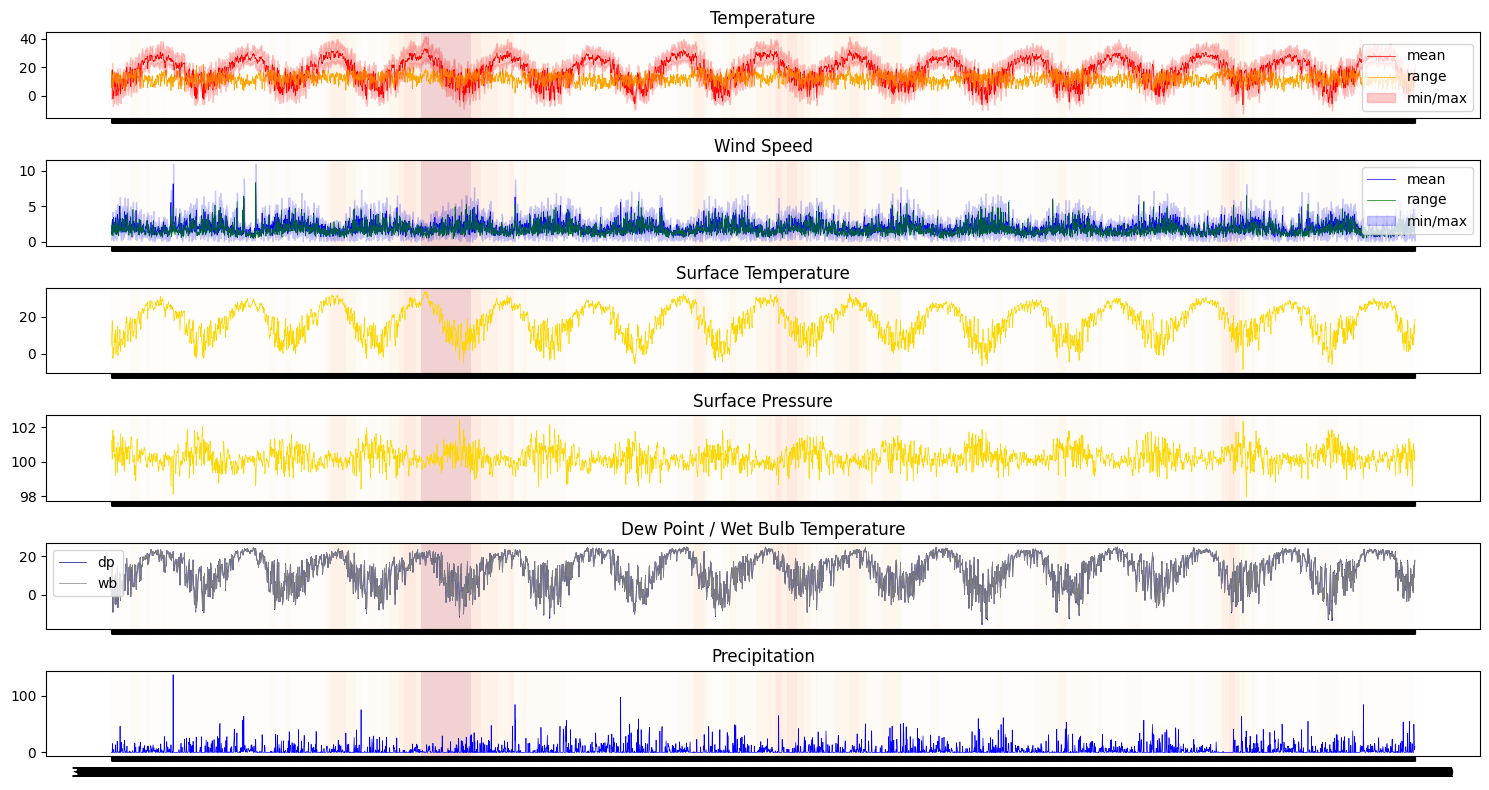

In [50]:
data_frame_to_figures(df_1)

In [ ]:
# seen = [False for _ in range(6)]
# df_list = [None for _ in range(6)]
# cnt = 0

# i = 0
# while cnt <= 5:
#     i += 1
#     df = file_csv_to_df(True, i)
#     label = df['label'][0]
#     if (not seen[label]):
#         df_list[label] = df
#         seen[label] = True
#         cnt += 1
#         print(f"label: {label} | file_id: {i}")

In [ ]:
# for i in range(6):
#     data_frame_to_figures(df_list[i])